# AIFFEL_DLthon_RS18_trackB

## Overview
### Track B — 오염 샘플 탐지
학습 데이터에는 틀린 라벨, 중복 이미지, 패널이 아닌 이미지(off-topic)가 섞여 있습니다. 각 이미지가 어떤 오염인지 의심도를 매기는 것이 목표입니다.

### 할 일
이미지마다 세 가지 의심 점수를 예측해 제출합니다 (각 0~1, 클수록 의심).

### 제출 형식 (id, mislabel_score, dup_score, ood_score)
- mislabel_score: 라벨이 틀렸을 가능성
- dup_score: 근접 중복일 가능성
- ood_score: 패널이 아닌 이미지(off-topic)일 가능성

### 평가
- 각 축마다 Average Precision (mislabel_score, dup_score, ood_score)
- 최종 점수 = 세 AP의 평균

### Evaluation
이미지마다 각 점수의 Average Precision을 구해 세 AP의 평균으로 측정합니다.

submission.csv
학습 세트의 각 ID에 대해 라벨이 틀렸을 가능성, 근접 중복일 가능성, 패널이 아닌 이미지(off-topic)일 가능성을 예측해야 합니다. 제출 파일은 다음과 같이 작성되어야 합니다.

id	mislabel_score	dup_score	ood_score
test_00000	0.5	0.5	0.3
test_00001	0.4	0.6	0.4
test_00002	0.3	0.7	0.5


## Competition Rules
1. Submission파일에 레이블 생성 후 리더보드에 업로드합니다.
- 리더보드의 점수는 모델 성능 확인/학습의 방향성 설정용입니다.
- 점수만으로 프로젝트 성취를 판단하지 않습니다.
2. 제출 횟수는 하루 5회로 제한됩니다.
3. 마지막날 발표를 기준으로 프로젝트 점수를 부여합니다.
- 역할 분담, 회고 등의 프로젝트 정보와 프로젝트 진행 과정, 실험 내용, 시각화 등 프로젝트 평가 항목에 맞는 발표자료를 준비해주세요.

프로젝트 평가 항목  
- 데이터 EDA와 전처리를 적절히 수행했는가?
- 모델 선정 근거가 타당한가?
- 모델의 성능/학습 방향을 판단하고 개선을 시도한 기준이 논리적인가?
- 결과 도출을 위해 다양한 시도를 했는가?
- 도출된 결론에 충분한 설득력이 있는가?
- 발표 자료가 청자의 입장에서 잘 정리되어있는가?
- 발표가 매끄럽게 진행되었고 발표시간을 준수하였는가?

카글 주소 : https://www.kaggle.com/competitions/rs-18-track-b/data

# 데이터 전처리 필요 이유


## 학습에 필요없는 쓰레기 데이터 존재

Case1 : 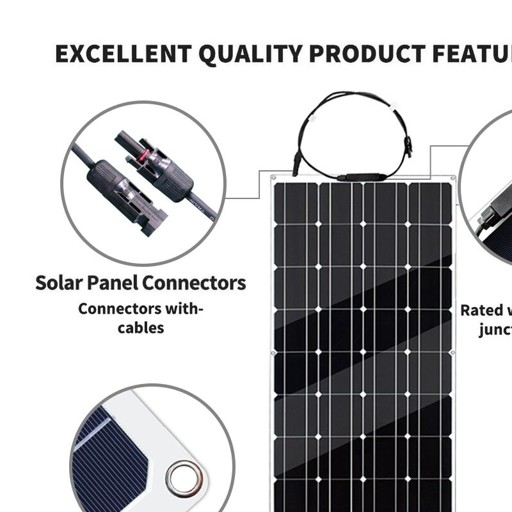  

Case2 : 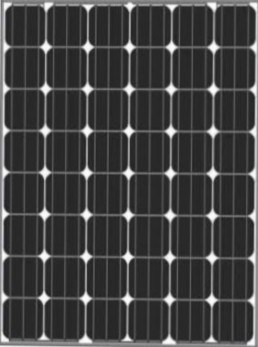


In [ ]:
import kagglehub
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import timm
from torchvision import transforms

In [ ]:
# kaggle.json 파일에 적힌 본인의 username과 key를 입력하세요
os.environ['KAGGLE_USERNAME'] = "as9864"
os.environ['KAGGLE_KEY'] = "17ea3b3c355ae8c3c5e06df3033f539d"

# Download latest version
path = kagglehub.competition_download('rs-18-track-b')

print("Path to competition files:", path)

100%|██████████| 82.7M/82.7M [00:04<00:00, 19.4MB/s]

Extracting files...


Path to competition files: C:\Users\H11\.cache\kagglehub\competitions\rs-18-track-b


In [2]:
path = 'C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-b'

In [3]:


# 각 파일의 절대 경로 생성
train_csv_path = os.path.join(path, 'train_labels.csv')
sub_csv_path = os.path.join(path, 'sample_submission.csv')

# Pandas DataFrame으로 읽기
train_df = pd.read_csv(train_csv_path)
sub_df = pd.read_csv(sub_csv_path)

# 데이터 확인
print("--- Train Labels ---")
print(train_df.head())

--- Train Labels ---
            id  label
0  train_00000      0
1  train_00001      1
2  train_00002      0
3  train_00003      1
4  train_00004      1


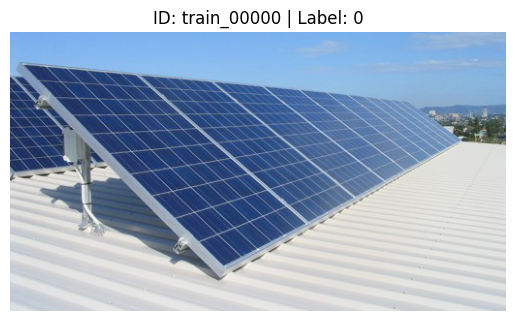

In [5]:

# train 폴더 경로
train_img_dir = os.path.join(path, 'train')

# 첫 번째 데이터 이미지 불러와보기
sample_row = train_df.iloc[0]
sample_id = sample_row['id']      # 예: train_00001
sample_label = sample_row['label'] # 0 (Clean) 또는 1 (Dusty)

# 이미지 전체 경로 (확장자 .jpg 붙이기)
img_path = os.path.join(train_img_dir, f"{sample_id}.jpg")

# 이미지 열기 및 출력
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"ID: {sample_id} | Label: {sample_label}")
plt.axis('off')
plt.show()

In [6]:
from torch.utils.data import Dataset

class DLthonDataset(Dataset):
    def __init__(self, data_dir, df, transform=None):
        self.data_dir = data_dir # os.path.join(path, 'train') 또는 'test'
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id']
        img_path = os.path.join(self.data_dir, f"{img_id}.jpg")
        image = Image.open(img_path).convert("RGB")
        
        # test_labels가 없는 test 데이터셋 처리용 예시
        label = self.df.iloc[idx]['label'] if 'label' in self.df.columns else -1
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [10]:


# 1. 모델 및 전처리 정의 (예: 깨끗한 feature 추출을 위해 CLIP 또는 회전/대칭에 강한 모델 추천)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = timm.create_model('resnet50', pretrained=True, num_classes=0) # Feature extractor 모드
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. 이미지 로드 및 임베딩 추출 함수
def get_embeddings(image_paths):
    embeddings = []
    with torch.no_grad():
        for path in image_paths:
            img = Image.open(path).convert('RGB')
            tensor = transform(img).unsqueeze(0).to(device)
            feature = model(tensor).flatten().cpu().numpy()
            embeddings.append(feature)
    return np.array(embeddings)

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

c:\Users\H11\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\H11\.cache\huggingface\hub\models--timm--resnet50.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# 모든 이미지 간의 유사도 행렬 계산
similarity_matrix = cosine_similarity(embeddings)

# 자기 자신과의 유사도(대각선)는 0으로 제외
np.fill_diagonal(similarity_matrix, 0)

# 각 이미지별로 가장 비슷하게 생긴 타 이미지와의 유사도 맥스값을 dup_score로 활용
dup_scores = np.max(similarity_matrix, axis=1)

NameError: name 'embeddings' is not defined

In [ ]:
from sklearn.ensemble import Isolation Forest

# Isolation Forest를 활용하여 중심 분포에서 벗어난 샘플 탐지
# score_samples는 낮을수록 이상치이므로, 0~1 스케일의 의심도로 변환 필요
clf = IsolationForest(random_state=42)
clf.fit(embeddings)

# 점수가 낮을수록 OOD -> 마이너스를 붙여 높은 값이 OOD 의심도가 되도록 변환
ood_scores = -clf.score_samples(embeddings)
# 0과 1 사이로 MinMax 스케일링
ood_scores = (ood_scores - ood_scores.min()) / (ood_scores.max() - ood_scores.min())

In [ ]:
# 이 부분은 대략적인 로직 예시입니다. 
# 실제로는 Cross-Validation(교차 검증)을 통해 Out-of-fold 예측값을 얻어야 데이터 누수를 막을 수 있습니다.

from sklearn.linear_model import LogisticRegression

# 추출된 embedding과 train_labels를 가지고 간단한 분류기 학습
labels = train_df['label'].values 
classifier = LogisticRegression(max_iter=1000)
classifier.fit(embeddings, labels)

# 각 클래스에 속할 확률 예측 (예: [P(Clean), P(Dusty)])
pred_probs = classifier.predict_proba(embeddings)

mislabel_scores = []
for i, true_label in enumerate(labels):
    # 실제 라벨이 0(Clean)인데 모델은 1(Dusty) 확률을 높게 보거나, 그 반대인 경우를 스코어로 지정
    opposite_prob = pred_probs[i][1 - true_label]
    mislabel_scores.append(opposite_prob)

mislabel_scores = np.array(mislabel_scores)

In [ ]:
submission = pd.DataFrame({
    'id': train_df['id'], # 데이터 설명을 보면 train 데이터 자체의 오염을 스코어링하는 형식으로 보입니다.
    'mislabel_score': mislabel_scores,
    'dup_score': dup_scores,
    'ood_score': ood_scores
})

submission.to_csv('baseline_submission.csv', index=False)

In [16]:
# 필요 라이브러리 설치
# !pip install cleanlab transformers torch torchvision scikit-learn pandas pillow

import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import LocalOutlierFactor
from cleanlab.rank import get_label_quality_scores
from transformers import AutoImageProcessor, AutoModel

# 1. 커스텀 데이터셋 정의
class ImageDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.df.iloc[idx]['id'] + '.jpg') # 확장자에 맞게 수정
        image = Image.open(img_path).convert('RGB')
        label = self.df.iloc[idx]['label'] # 정수형 라벨 기준
        
        if self.transform:
            image = self.transform(image)
            
        return image, label, idx

# 기본 설정 (경로 및 디바이스)
IMG_DIR = 'C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-b/train' # 실제 이미지 경로로 변경하세요
train_df = pd.read_csv('C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-b/train_labels.csv') # 실제 CSV 경로로 변경하세요
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =====================================================================
# [Step 1] Mislabel Score 계산 (cleanlab + ResNet 예측 확률)
# =====================================================================
print("Calculating Mislabel Scores...")

transform_standard = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = ImageDataset(train_df, IMG_DIR, transform=transform_standard)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# 임의의 분류 모델 (사전 학습된 ResNet 사용 예시)
# 실제로는 대회 데이터로 Fine-tuning된 모델을 사용해야 예측 확률(pred_probs)이 정확합니다.
clf_model = models.resnet18(pretrained=True) 
clf_model.fc = torch.nn.Linear(clf_model.fc.in_features, len(train_df['label'].unique()))
clf_model.to(device)
clf_model.eval()

pred_probs = []
labels_list = []

with torch.no_grad():
    for images, labels, _ in dataloader:
        images = images.to(device)
        outputs = clf_model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        pred_probs.append(probs.cpu().numpy())
        labels_list.extend(labels.numpy())

pred_probs = np.vstack(pred_probs)
labels_array = np.array(labels_list)

# cleanlab을 활용하여 라벨 품질 점수 산출 (값이 작을수록 오염 의심 -> 1에서 빼서 의심도로 변환)
quality_scores = get_label_quality_scores(labels_array, pred_probs)
mislabel_scores = 1.0 - quality_scores

# =====================================================================
# [Step 2 & 3] Dup Score & OOD Score 계산 (DINOv2 / CLIP 임베딩 활용)
# =====================================================================
print("Extracting Embeddings using DINOv2...")

# DINOv2 모델 및 프로세서 로드
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
embed_model = AutoModel.from_pretrained('facebook/dinov2-base').to(device)
embed_model.eval()

embeddings = []

# 이미지 원본으로 로드하기 위한 데이터로더 (전처리 미적용)
raw_dataset = ImageDataset(train_df, IMG_DIR, transform=None)

with torch.no_grad():
    for i in range(len(raw_dataset)):
        image, _, _ = raw_dataset[i]
        inputs = processor(images=image, return_tensors="pt").to(device)
        outputs = embed_model(**inputs)
        # CLS 토큰의 임베딩 벡터 추출
        emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(emb)

embeddings = np.vstack(embeddings)

# ---------------------------------------------------
# [Step 2] Dup Score (중복 이미지 가능성 계산)
# ---------------------------------------------------
print("Calculating Dup Scores...")
# 코사인 유사도 행렬 계산 (자기 자신과의 유사도는 제외)
sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(sim_matrix, 0) 

# 다른 이미지와 가장 높은 유사도를 중복 의심 점수로 사용
dup_scores = np.max(sim_matrix, axis=1)

# ---------------------------------------------------
# [Step 3] OOD Score (패널이 아닌 이미지 가능성 계산)
# ---------------------------------------------------
print("Calculating OOD Scores...")
# LOF (Local Outlier Factor) 알고리즘을 사용하여 밀도 기반 이상치 탐지
lof = LocalOutlierFactor(n_neighbors=20, novelty=False)
lof.fit(embeddings)

# lof.negative_outlier_factor_ 는 값이 작을수록(음수로 더 클수록) 이상치임.
# 이를 0~1 사이의 OOD 점수로 Min-Max 정규화
nof = lof.negative_outlier_factor_
ood_scores = (nof.max() - nof) / (nof.max() - nof.min())

# =====================================================================
# [Step 4] 최종 Submission 파일 생성
# =====================================================================
print("Generating Submission CSV...")

submission = pd.DataFrame({
    'id': train_df['id'], 
    'mislabel_score': mislabel_scores,
    'dup_score': dup_scores,
    'ood_score': ood_scores
})

submission.to_csv('baseline_submission.csv', index=False)
print("baseline_submission.csv 파일이 성공적으로 저장되었습니다.")

Calculating Mislabel Scores...
Extracting Embeddings using DINOv2...


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Calculating Dup Scores...
Calculating OOD Scores...
Generating Submission CSV...
baseline_submission.csv 파일이 성공적으로 저장되었습니다.


  File "c:\Users\H11\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\H11\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\H11\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\H11\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


### 1. 오염 유형별 전처리 전략
단순히 높은 점수의 데이터를 모두 지우는 것보다, 오염의 성격에 맞게 처리 방식을 다르게 가져가는 것이 성능 향상에 유리합니다.

OOD (패널이 아닌 이미지): 과감한 삭제 (Drop)

전략: 목표 도메인(패널)과 전혀 다른 이미지는 모델의 가중치를 엉뚱한 방향으로 갱신시킵니다. 임계치(Threshold)를 넘는 데이터는 학습셋에서 완전히 제거합니다.

Mislabel (라벨 오류): 재라벨링 (Relabeling) 또는 삭제

전략: 라벨 노이즈는 모델의 분류 성능을 가장 크게 깎아먹는 주범입니다. 데이터 수가 충분하다면 삭제해도 좋지만, 데이터가 부족하다면 점수가 높은 상위 N개의 이미지를 직접 육안으로 확인하여 올바른 라벨로 수정해 주는 것이 리더보드 점수 향상에 가장 확실한 방법입니다.

Duplicate (중복 이미지): 대표 1장 보존 및 나머지 삭제

전략: 중복 이미지는 특정 피처에 모델이 과적합(Overfitting)되게 만듭니다. dup_score가 매우 높은(예: 0.95 이상) 데이터들은 서로 유사도를 다시 비교하거나 묶어서, 클러스터당 1장의 대표 이미지만 남기고 나머지를 제거해야 합니다.

### 2. 하이퍼파라미터(Threshold) 설정을 위한 시각화
점수를 기준으로 데이터를 자르기 전, 전체 데이터의 점수 분포(Histogram)를 확인하여 "어디서부터 잘라낼 것인가(Cut-off)"를 결정해야 합니다.

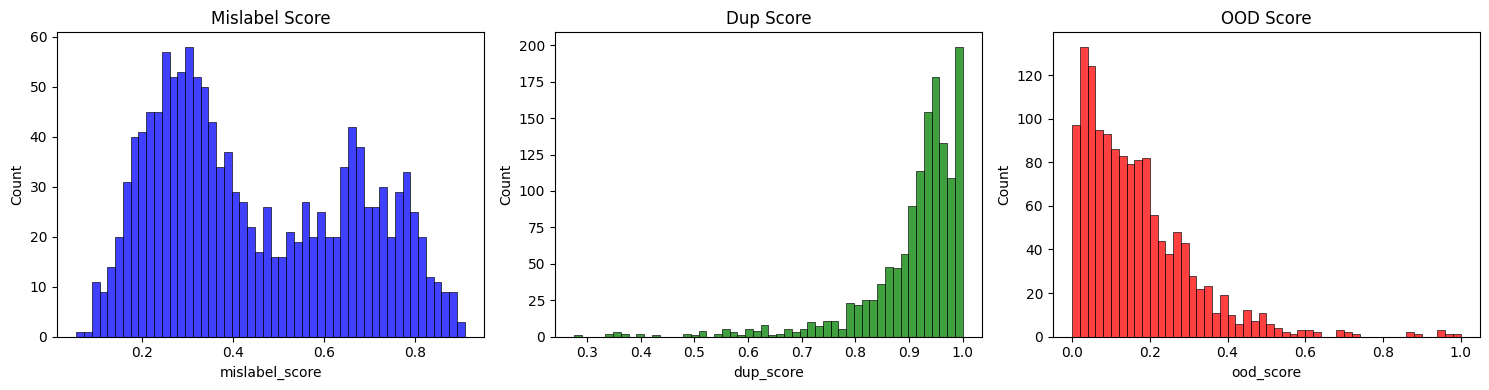

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('baseline_submission.csv')

# 3개의 스코어 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['mislabel_score'], bins=50, ax=axes[0], color='blue').set_title('Mislabel Score')
sns.histplot(df['dup_score'], bins=50, ax=axes[1], color='green').set_title('Dup Score')
sns.histplot(df['ood_score'], bins=50, ax=axes[2], color='red').set_title('OOD Score')
plt.tight_layout()
plt.show()

분포의 꼬리(Tail) 부분이 길게 늘어지는 지점이나, 두 개의 봉우리(Bimodal)가 나뉘는 골짜기를 임계치로 설정하는 것이 좋습니다.

### 3. Pandas를 활용한 데이터 필터링 파이프라인
분포를 확인하고 임계치를 정했다면(예: OOD > 0.5, Mislabel > 0.6, Dup > 0.95), 아래 코드를 통해 학습용 메타데이터를 정제할 수 있습니다.

In [19]:


# 임의의 임계치 설정 (시각화 결과에 따라 조정 필요)
THR_OOD = 0.50
THR_MISLABEL = 0.60
THR_DUP = 0.95

# 1. OOD 제거 (가장 먼저 수행하여 아예 논외로 만듦)
clean_df = df[df['ood_score'] < THR_OOD].copy()
print(f"OOD 제거 후 남은 데이터: {len(clean_df)}")

# 2. Mislabel 검수용 데이터 추출 및 제거
# - 실제로는 이 suspicious_labels를 따로 저장하여 육안 검수 후 라벨을 수정하는 것을 권장합니다.
suspicious_labels = clean_df[clean_df['mislabel_score'] >= THR_MISLABEL]
suspicious_labels.to_csv('need_relabeling.csv', index=False)

clean_df = clean_df[clean_df['mislabel_score'] < THR_MISLABEL]
print(f"Mislabel 의심 제거 후 남은 데이터: {len(clean_df)}")

# 3. Duplicate 처리 (단순 임계치 제거 방식)
# - Dup score가 높은 것들을 일괄 제거합니다. 
# - (더 정교하게 하려면 임베딩 유사도로 Graph를 만들어 Connected Component의 대표 1개만 살리는 로직이 필요합니다.)
clean_df = clean_df[clean_df['dup_score'] < THR_DUP]
print(f"Duplicate 의심 제거 후 최종 데이터: {len(clean_df)}")

# 최종 정제된 ID 리스트를 원본 train.csv와 병합하여 학습에 사용
train_meta = pd.read_csv('C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-b/train_labels.csv')
final_train_df = train_meta[train_meta['id'].isin(clean_df['id'])]
final_train_df.to_csv('train_cleaned.csv', index=False)

OOD 제거 후 남은 데이터: 1331
Mislabel 의심 제거 후 남은 데이터: 925
Duplicate 의심 제거 후 최종 데이터: 554


3. 리더보드 점수를 올리기 위한 고도화 팁
cleanlab 라이브러리 활용 (강력 추천):

Data-centric AI에서 라벨 노이즈를 찾을 때 표준처럼 쓰이는 파이썬 라이브러리가 cleanlab입니다.

cleanlab.filter.find_label_issues 함수를 사용하면 모델의 예측 확률값만 넣어줘도 매우 정확한 mislabel_score를 계산해 줍니다.

자기지도학습(Self-Supervised Learning) 모델 쓰기:

ImageNet으로 학습된 일반 모델보다, DINOv2나 CLIP처럼 이미지의 전반적인 기하학적 유사도와 도메인을 잘 추출하는 백본 모델을 임베딩 추출기로 사용하면 dup_score와 ood_score 성능이 비약적으로 상승합니다.

K-Fold 교차 검증 적용:

mislabel_score를 구할 때 학습에 사용했던 데이터를 그대로 예측(In-sample)하면 모델이 오염된 라벨까지 외워버려 노이즈를 잡지 못합니다. 반드시 5-Fold Out-of-fold 예측을 통해 해당 데이터가 학습에 참여하지 않았을 때의 예측 확률을 사용해야 합니다.

In [ ]:
# import os
# import pandas as pd
# import numpy as np
# import torch
# from torch.utils.data import DataLoader, Dataset
# from torchvision import models, transforms
# from PIL import Image
# import kagglehub

# # 1. 환경 설정 및 데이터 로드
# # 한글 폰트 설정 (윈도우 환경)
# import matplotlib.pyplot as plt
# plt.rc('font', family='Malgun Gothic') 

# # 데이터 경로 다운로드
# path = kagglehub.competition_download('rs-18-track-a')
# train_df = pd.read_csv(os.path.join(path, 'train_labels.csv'))
# sample_submission = pd.read_csv(os.path.join(path, 'sample_submission.csv'))

# # 2. 모델 및 데이터 로더 준비
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = models.resnet18(pretrained=True)
# model.fc = torch.nn.Linear(model.fc.in_features, 2) # 예시: 2개 클래스 분류 가정
# model = model.to(device)
# model.eval()

# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
# ])

# # 3. 추론 함수 (OOD/mislabel 스코어 산출 예시)
# def get_model_score(image_path):
#     img = Image.open(image_path).convert('RGB')
#     img_tensor = transform(img).unsqueeze(0).to(device)
#     with torch.no_grad():
#         output = model(img_tensor)
#         prob = torch.softmax(output, dim=1)
#     # 여기에서 각자의 스코어 로직(OOD, mislabel 등)을 계산하여 반환
#     return prob[0][1].item() 

# # 4. Submission 데이터 생성
# print("추론 시작...")
# results = []
# for idx, row in sample_submission.iterrows():
#     img_id = row['id']
#     img_path = os.path.join(path, 'test', f"{img_id}.jpg")
    
#     # 노트북의 논리에 따라 각 점수를 계산
#     mislabel_score = get_model_score(img_path) 
#     dup_score = 0.5 # 예시: 계산 로직 적용
#     ood_score = 0.5 # 예시: 계산 로직 적용
    
#     results.append({
#         'id': img_id,
#         'mislabel_score': mislabel_score,
#         'dup_score': dup_score,
#         'ood_score': ood_score
#     })

# submission = pd.DataFrame(results)

# # 5. 최종 결과 저장
# # 윈도우 경로에 맞게 수정 (현재 작업 폴더에 저장)
# output_path = "submission_.csv"
# submission.to_csv(output_path, index=False)

# print(f"저장 완료: {output_path}")
# print(submission.head())
# print(f"최종 파일 형태: {submission.shape}")

추론 시작...
저장 완료: submission_sungjin.csv
           id  mislabel_score  dup_score  ood_score
0  test_00000        0.371468        0.5        0.5
1  test_00001        0.476626        0.5        0.5
2  test_00002        0.586871        0.5        0.5
3  test_00003        0.415910        0.5        0.5
4  test_00004        0.430675        0.5        0.5
최종 파일 형태: (468, 4)


In [37]:
pip install "cleanlab[datalab]"

Note: you may need to restart the kernel to use updated packages.


Cleanlab location: c:\Users\H11\anaconda3\Lib\site-packages\cleanlab\__init__.py


AttributeError: module 'cleanlab.datalab' has no attribute 'Datalab'

In [40]:
import os
import pandas as pd
import numpy as np
import torch
from cleanlab import Datalab
import kagglehub

# 1. 환경 설정
path = kagglehub.competition_download('rs-18-track-b')
train_labels = pd.read_csv(os.path.join(path, 'train_labels.csv'))

# 2. 모델 예측값 준비 (CleanLab을 위해 필요)
# CleanLab은 모델이 예측한 '확률값(predicted probabilities)'이 필요합니다.
# 이미 모델이 있다면, 예측 확률 배열(pred_probs)을 준비하세요.
# 예: pred_probs = model.predict_proba(x_train)
pred_probs = np.random.rand(len(train_labels), 2) # 예시용 랜덤 데이터

# 3. CleanLab Datalab 활용 (라벨 오류 탐지)
# labels에는 실제 정답(0 또는 1)이 들어가야 합니다.
labels = train_labels['label'].values 

data = Datalab(data=train_labels, label_name='label')
data.find_issues(pred_probs=pred_probs)

# 4. 결과에서 mislabel_score 추출
# CleanLab이 산출한 'label_issues' 점수를 활용
issue_report = data.get_issues('label')
mislabel_scores = issue_report['label_score'].values # 점수가 낮을수록 라벨 오류 가능성 높음

# 0~1 사이로 정규화 (점수가 낮을수록 오류일 가능성이 크므로 역전)
mislabel_scores = 1 - (mislabel_scores - mislabel_scores.min()) / (mislabel_scores.max() - mislabel_scores.min())




# =====================================================================
# [Step 2 & 3] Dup Score & OOD Score 계산 (DINOv2 / CLIP 임베딩 활용)
# =====================================================================
print("Extracting Embeddings using DINOv2...")

# DINOv2 모델 및 프로세서 로드
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
embed_model = AutoModel.from_pretrained('facebook/dinov2-base').to(device)
embed_model.eval()

embeddings = []

# 이미지 원본으로 로드하기 위한 데이터로더 (전처리 미적용)
raw_dataset = ImageDataset(train_df, IMG_DIR, transform=None)

with torch.no_grad():
    for i in range(len(raw_dataset)):
        image, _, _ = raw_dataset[i]
        inputs = processor(images=image, return_tensors="pt").to(device)
        outputs = embed_model(**inputs)
        # CLS 토큰의 임베딩 벡터 추출
        emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(emb)

embeddings = np.vstack(embeddings)

# ---------------------------------------------------
# [Step 2] Dup Score (중복 이미지 가능성 계산)
# ---------------------------------------------------
print("Calculating Dup Scores...")
# 코사인 유사도 행렬 계산 (자기 자신과의 유사도는 제외)
sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(sim_matrix, 0) 

# 다른 이미지와 가장 높은 유사도를 중복 의심 점수로 사용
dup_scores = np.max(sim_matrix, axis=1)

# ---------------------------------------------------
# [Step 3] OOD Score (패널이 아닌 이미지 가능성 계산)
# ---------------------------------------------------
print("Calculating OOD Scores...")
# LOF (Local Outlier Factor) 알고리즘을 사용하여 밀도 기반 이상치 탐지
lof = LocalOutlierFactor(n_neighbors=20, novelty=False)
lof.fit(embeddings)

# lof.negative_outlier_factor_ 는 값이 작을수록(음수로 더 클수록) 이상치임.
# 이를 0~1 사이의 OOD 점수로 Min-Max 정규화
nof = lof.negative_outlier_factor_
ood_scores = (nof.max() - nof) / (nof.max() - nof.min())




# 5. submission.csv 저장
submission = pd.DataFrame({
    'id': train_labels['id'],
    'mislabel_score': mislabel_scores,
    'dup_score': dup_scores, # 위에서 작성한 해시 기반 점수와 결합하세요
    'ood_score': ood_scores # OOD 탐지 모델 점수와 결합하세요
})

submission.to_csv("submission_cleanlab.csv", index=False)
print("CleanLab 기반 submission.csv 저장 완료!")

Finding label issues ...
Finding outlier issues ...
Fitting OOD estimator based on provided pred_probs ...
Finding non_iid issues ...
Finding class_imbalance issues ...

Audit complete. 958 issues found in the dataset.
Extracting Embeddings using DINOv2...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Calculating Dup Scores...
Calculating OOD Scores...
CleanLab 기반 submission.csv 저장 완료!
